# Laboratorio 3 - Reconocimiento de lenguaje de señas
## Análisis exploratorio 

Belén Monterroso 231497 

Melisa Mendizabal 23778 

Renato Rojas 23813


### Descarga de librerías necesarias

In [27]:
!pip install -q kaggle
!pip install -q pillow
!pip install -q pandas
!pip install -q matplotlib
!pip install -q numpy
!pip install imagehash --quiet


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Importación de librería y parámetros generales

El código importa las librerías necesarias para el manejo de archivos, datos, imágenes y visualización, además de configurar una semilla para obtener resultados reproducibles. También establece algunos parámetros de visualización y verifica que las librerías hayan sido cargadas correctamente.


In [28]:
import os
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, UnidentifiedImageError
from IPython.display import display

warnings.filterwarnings("ignore")

SEMILLA = 42

random.seed(SEMILLA)
np.random.seed(SEMILLA)


plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = False

print("Librerías importadas correctamente.")
print(f"Semilla utilizada: {SEMILLA}")

Librerías importadas correctamente.
Semilla utilizada: 42


### Obtener DataSet 
recorre las carpetas del dataset para identificar y registrar información de cada imagen, como su clase, nombre, dimensiones, formato y modo de color. Luego, organiza estos datos en un DataFrame de Pandas para facilitar su análisis

In [29]:
RUTA_DATASET = r"archive/asl_alphabet_train/asl_alphabet_train"

datos_img = []

for clase in sorted(os.listdir(RUTA_DATASET)):

    carpeta = os.path.join(RUTA_DATASET, clase)

    if not os.path.isdir(carpeta):
        continue

    for archivo in os.listdir(carpeta):

        ruta = os.path.join(carpeta, archivo)

        try:

            imagen = Image.open(ruta)

            ancho, alto = imagen.size

            datos_img.append({
                "clase": clase,
                "archivo": archivo,
                "ruta": ruta,
                "ancho": ancho,
                "alto": alto,
                "modo": imagen.mode,
                "formato": imagen.format
            })

        except Exception as e:

            print(f"No se pudo abrir {ruta}")

datos_img = pd.DataFrame(datos_img)



### Cantidad de registros

In [30]:
print("Cantidad total de imágenes:")
print(len(datos_img))


Cantidad total de imágenes:
87000


### Muestra de los registros


In [31]:
datos_img.head()

,clase,archivo,ruta,ancho,alto,modo,formato
0,A,A1.jpg,archive/asl_alphabet_train/asl_alphabet_train\...,200,200,RGB,JPEG
1,A,A10.jpg,archive/asl_alphabet_train/asl_alphabet_train\...,200,200,RGB,JPEG
2,A,A100.jpg,archive/asl_alphabet_train/asl_alphabet_train\...,200,200,RGB,JPEG
3,A,A1000.jpg,archive/asl_alphabet_train/asl_alphabet_train\...,200,200,RGB,JPEG
4,A,A1001.jpg,archive/asl_alphabet_train/asl_alphabet_train\...,200,200,RGB,JPEG


### Resoluciones de las imágenes
Se verifica si realmente todas las imágenes continen un tamaño estándar de pixeles.

In [32]:
print(datos_img[["ancho", "alto"]].drop_duplicates())

   ancho  alto
0    200   200


### Formatos de las imágenes

In [33]:
print("\nFormatos únicos:")
print(datos_img["formato"].value_counts())


Formatos únicos:
formato
JPEG    87000
Name: count, dtype: int64


### Modos de color

In [34]:
print("\nModos de color únicos (RGB, L, RGBA, etc.):")
print(datos_img["modo"].value_counts())


Modos de color únicos (RGB, L, RGBA, etc.):
modo
RGB    87000
Name: count, dtype: int64


### Cantidad y clases disponibles 

In [35]:
print(f"\nTotal de clases encontradas: {datos_img['clase'].nunique()}")
print(f"Clases: {sorted(datos_img['clase'].unique())}")


Total de clases encontradas: 29
Clases: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


### Distribución de cantidad de imágenes por clase 

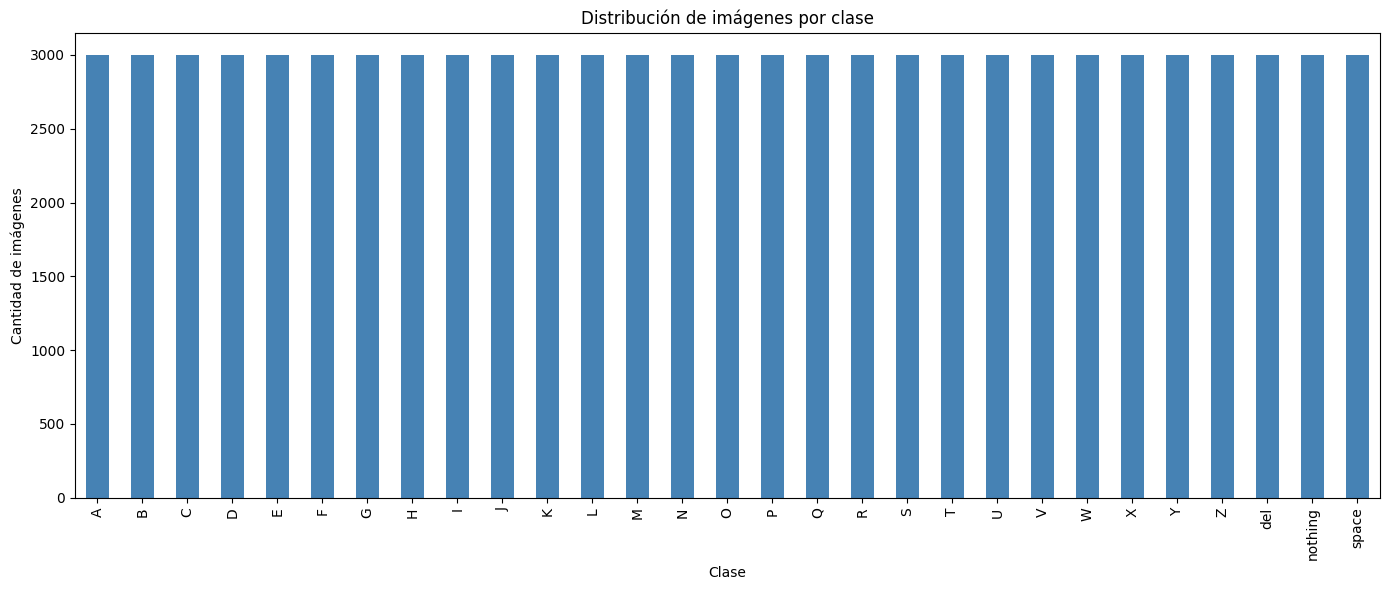

Mínimo: 3000 (A)
Máximo: 3000 (A)
Desviación estándar: 0.00
Coeficiente de variación: 0.00%


In [36]:
conteo_clases = datos_img["clase"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
conteo_clases.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Distribución de imágenes por clase")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de imágenes")
plt.tight_layout()
plt.show()

print(f"Mínimo: {conteo_clases.min()} ({conteo_clases.idxmin()})")
print(f"Máximo: {conteo_clases.max()} ({conteo_clases.idxmax()})")
print(f"Desviación estándar: {conteo_clases.std():.2f}")
print(f"Coeficiente de variación: {conteo_clases.std()/conteo_clases.mean()*100:.2f}%")

### Ejemplo de variabilidad de imágenes 

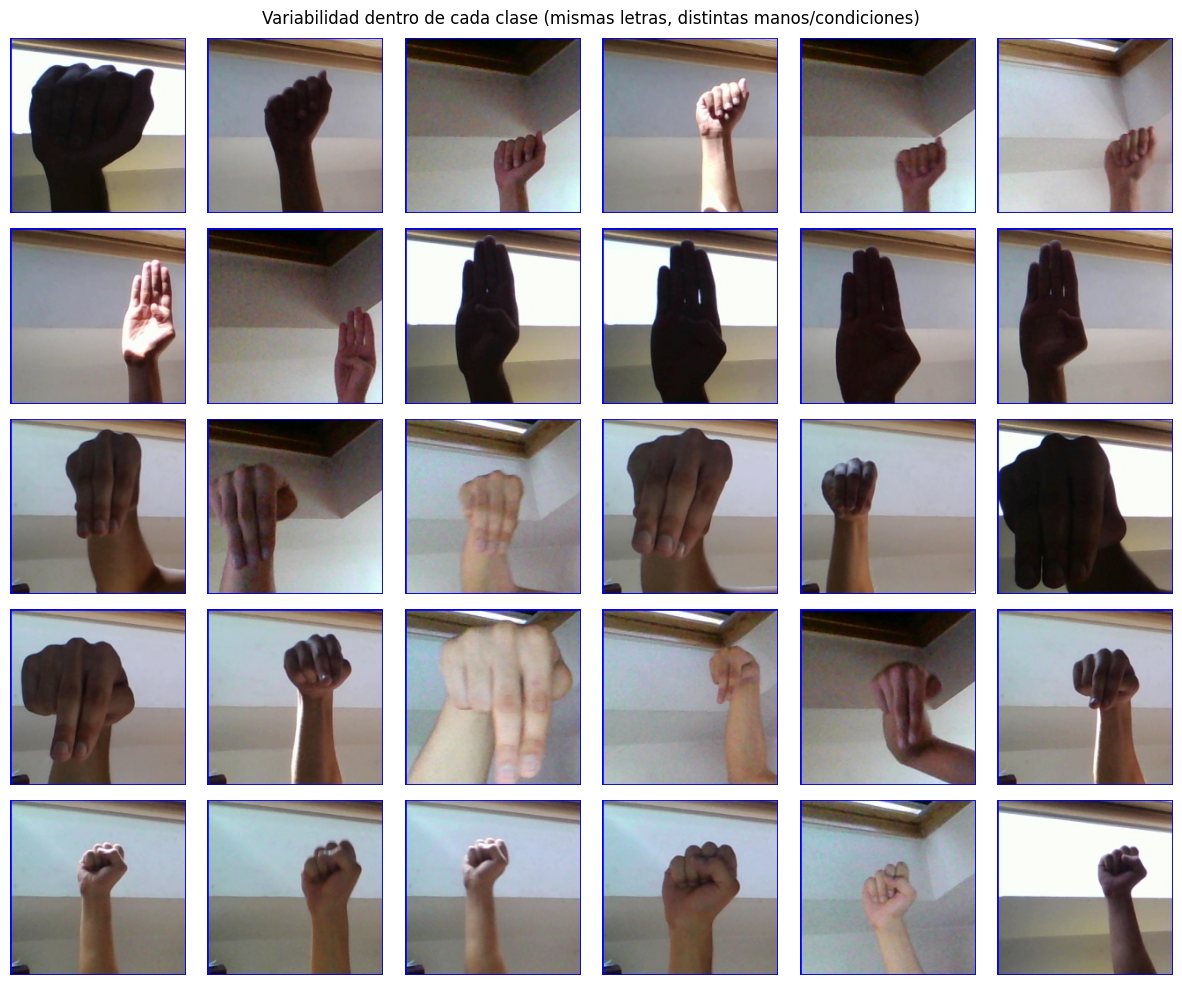

In [37]:
def mostrar_muestras(df, clases, n_por_clase=5, semilla=SEMILLA):
    fig, axes = plt.subplots(len(clases), n_por_clase, figsize=(n_por_clase*2, len(clases)*2))
    rng = np.random.default_rng(semilla)

    for i, clase in enumerate(clases):
        rutas_clase = df[df["clase"] == clase]["ruta"].values
        muestra = rng.choice(rutas_clase, size=n_por_clase, replace=False)

        for j, ruta in enumerate(muestra):
            img = Image.open(ruta)
            ax = axes[i, j] if len(clases) > 1 else axes[j]
            ax.imshow(img)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(clase, fontsize=12, rotation=0, labelpad=30)

    plt.suptitle("Variabilidad dentro de cada clase (mismas letras, distintas manos/condiciones)")
    plt.tight_layout()
    plt.show()

# Al menos 5 letras distintas, con varias muestras cada una para ver variabilidad
mostrar_muestras(datos_img, clases=["A", "B", "M", "N", "S"], n_por_clase=6)

## Similitud entre clases
### Comparación de clases solicitadas

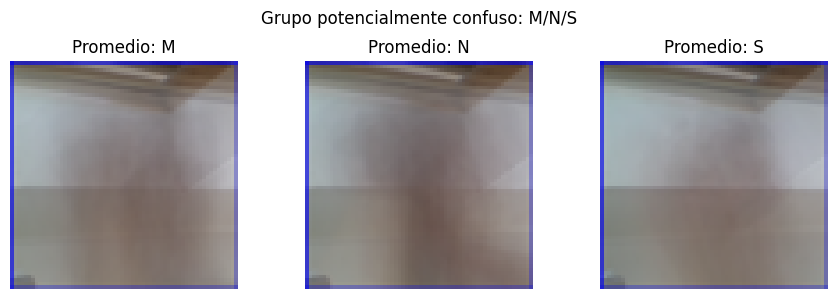


Distancias entre imágenes promedio del grupo M/N/S:
  M vs N: 1285.63
  M vs S: 1048.20
  N vs S: 1874.95


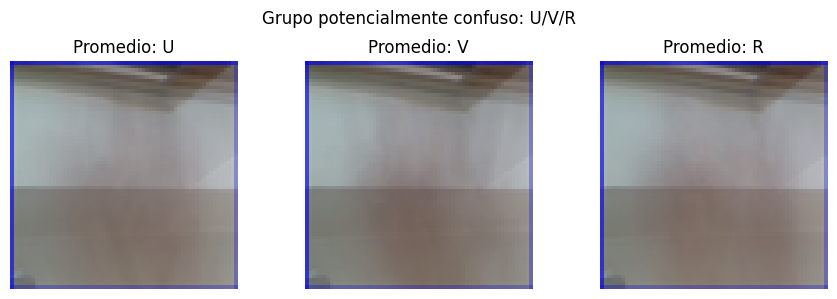


Distancias entre imágenes promedio del grupo U/V/R:
  U vs V: 525.02
  U vs R: 441.18
  V vs R: 546.11


In [ ]:
def imagen_promedio_por_clase(df, clase, tam=(64, 64), n_muestra=200, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    rutas = df[df["clase"] == clase]["ruta"].values
    n = min(n_muestra, len(rutas))
    muestra = rng.choice(rutas, size=n, replace=False)

    acumulador = np.zeros((*tam[::-1], 3), dtype=np.float64)
    for ruta in muestra:
        img = Image.open(ruta).convert("RGB").resize(tam)
        acumulador += np.array(img, dtype=np.float64)

    return (acumulador / n).astype(np.uint8)

grupos_a_comparar = {
    "M/N/S": ["M", "N", "S"],
    "U/V/R": ["U", "V", "R"],
}

for nombre_grupo, letras in grupos_a_comparar.items():
    fig, axes = plt.subplots(1, len(letras), figsize=(len(letras)*3, 3))
    promedios = {}
    for ax, letra in zip(axes, letras):
        prom = imagen_promedio_por_clase(datos_img, letra)
        promedios[letra] = prom
        ax.imshow(prom)
        ax.set_title(f"Promedio: {letra}")
        ax.axis("off")
    plt.suptitle(f"Grupo potencialmente confuso: {nombre_grupo}")
    plt.tight_layout()
    plt.show()

    # Similitud entre las imágenes promedio (distancia euclidiana normalizada)
    print(f"\nDistancias entre imágenes promedio del grupo {nombre_grupo}:")
    for i in range(len(letras)):
        for j in range(i+1, len(letras)):
            l1, l2 = letras[i], letras[j]
            dist = np.linalg.norm(
                promedios[l1].astype(np.float64) - promedios[l2].astype(np.float64)
            )
            print(f"  {l1} vs {l2}: {dist:.2f}")

### Comparación general entre clases en busca de similitudes

In [ ]:
from itertools import combinations
from scipy.spatial.distance import pdist, squareform

# Calcular la imagen promedio de CADA clase una sola vez (el costo real, 29 veces)
clases = sorted(datos_img["clase"].unique())
promedios = {clase: imagen_promedio_por_clase(datos_img, clase) for clase in clases}

# Apilar todas las imágenes promedio como vectores en una sola matriz 
matriz_promedios = np.array([promedios[c].astype(np.float64).flatten() for c in clases])

# Calcular TODAS las distancias par a par de una sola vez (vectorizado, sin loops anidados) 
distancias = squareform(pdist(matriz_promedios, metric="euclidean"))
distancias_df = pd.DataFrame(distancias, index=clases, columns=clases)

#  Extraer automáticamente los pares MÁS parecidos (mayor riesgo de confusión) 
pares = [
    (clases[i], clases[j], distancias[i, j])
    for i, j in combinations(range(len(clases)), 2)
]
pares_df = pd.DataFrame(pares, columns=["clase_1", "clase_2", "distancia"]).sort_values("distancia")

print("Los 10 pares de letras MÁS parecidas (mayor riesgo de confusión para el modelo):")
print(pares_df.head(10).to_string(index=False))

print("\nLos 5 pares MÁS distintos (referencia de qué tan grande es una diferencia 'normal'):")
print(pares_df.tail(5).to_string(index=False))

Los 10 pares de letras MÁS parecidas (mayor riesgo de confusión para el modelo):
clase_1 clase_2  distancia
      V       W 388.221586
      R       U 441.182502
      U       W 521.463326
      U       V 525.016190
      R       V 546.108048
      V       Y 568.140828
      R       W 592.572358
      U       Y 616.952186
      T       W 619.619238
      W       Y 630.610815

Los 5 pares MÁS distintos (referencia de qué tan grande es una diferencia 'normal'):
clase_1 clase_2   distancia
      F nothing 3767.215550
      E nothing 3771.801029
      H nothing 3836.437671
      G nothing 3856.593315
      A nothing 4221.872215


### Mapa de calor de distancia entre imágenes

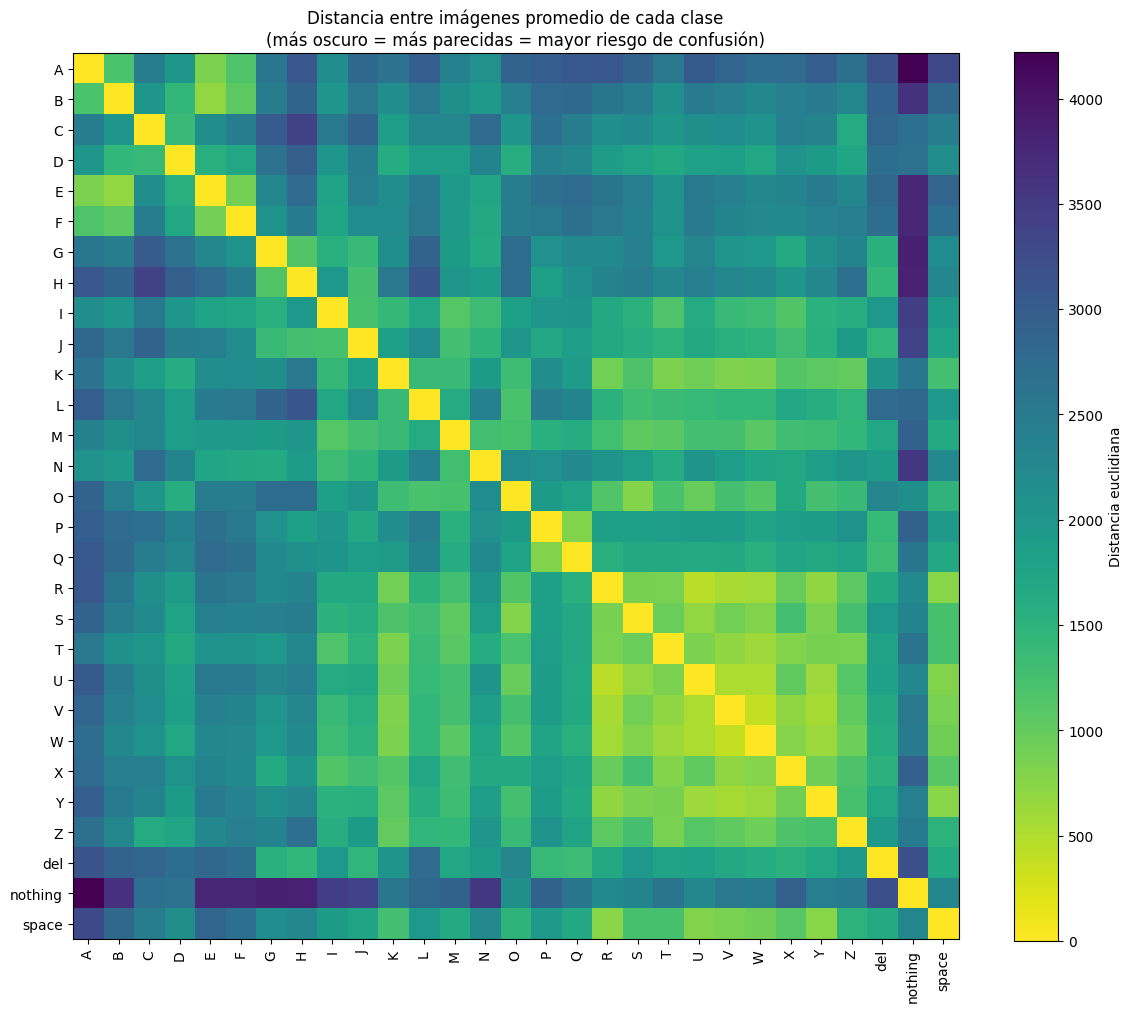

In [40]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(distancias_df.values, cmap="viridis_r")  # invertido: oscuro = más parecido
ax.set_xticks(range(len(clases)))
ax.set_yticks(range(len(clases)))
ax.set_xticklabels(clases, rotation=90)
ax.set_yticklabels(clases)
ax.set_title("Distancia entre imágenes promedio de cada clase\n(más oscuro = más parecidas = mayor riesgo de confusión)")
plt.colorbar(im, ax=ax, label="Distancia euclidiana")
plt.tight_layout()
plt.show()

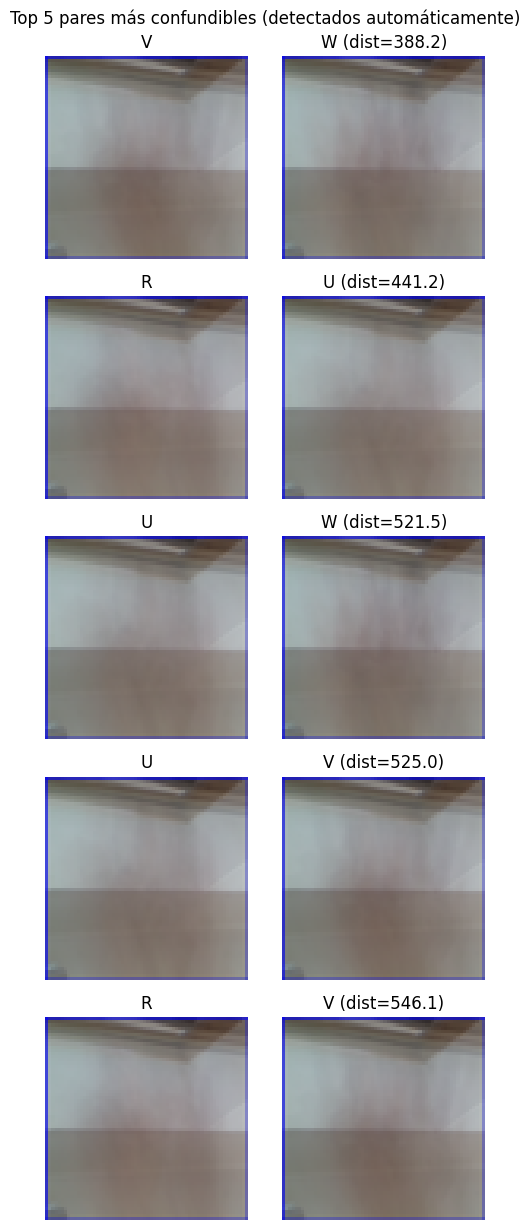

In [41]:
top_n = 5
top_pares = pares_df.head(top_n)

fig, axes = plt.subplots(top_n, 2, figsize=(5, top_n*2.5))
for idx, (_, fila) in enumerate(top_pares.iterrows()):
    axes[idx, 0].imshow(promedios[fila["clase_1"]])
    axes[idx, 0].set_title(f"{fila['clase_1']}")
    axes[idx, 0].axis("off")

    axes[idx, 1].imshow(promedios[fila["clase_2"]])
    axes[idx, 1].set_title(f"{fila['clase_2']} (dist={fila['distancia']:.1f})")
    axes[idx, 1].axis("off")

plt.suptitle(f"Top {top_n} pares más confundibles (detectados automáticamente)")
plt.tight_layout()
plt.show()

xd

In [42]:
import imagehash

def calcular_hash(ruta, hash_size=16):
    try:
        img = Image.open(ruta)
        # hash_size mayor = huella más detallada = menos colisiones falsas
        return str(imagehash.phash(img, hash_size=hash_size))
    except Exception:
        return None

def son_realmente_duplicados(ruta1, ruta2, tam=(64, 64), umbral_mse=15):
    """Verificación adicional: compara los píxeles de verdad, no solo el hash."""
    img1 = np.array(Image.open(ruta1).convert("RGB").resize(tam), dtype=np.float64)
    img2 = np.array(Image.open(ruta2).convert("RGB").resize(tam), dtype=np.float64)
    mse = np.mean((img1 - img2) ** 2)
    return mse < umbral_mse, mse


   

In [43]:
def calcular_brillo(ruta, tam=(64, 64)):
    img = Image.open(ruta).convert("RGB").resize(tam)
    return np.array(img, dtype=np.float64).mean()



In [ ]:
from sklearn.model_selection import train_test_split

# --- 1. Submuestra por clase ---
N_POR_CLASE = 600

submuestra = (
    datos_img.groupby("clase", group_keys=False)
    .apply(lambda x: x.sample(n=min(N_POR_CLASE, len(x)), random_state=SEMILLA))
    .reset_index(drop=True)
)

# --- 2. Calcular hash perceptual para toda la submuestra ---
#submuestra["phash"] = submuestra["ruta"].apply(calcular_hash)

submuestra["phash"] = submuestra["ruta"].apply(lambda r: calcular_hash(r, hash_size=16))

duplicados = submuestra[submuestra.duplicated(subset="phash", keep=False)]
print(f"Imágenes duplicadas encontradas (hash_size=16): {len(duplicados)} de {len(submuestra)}")

duplicados_cross_clase = (
    duplicados.groupby("phash")["clase"].nunique().reset_index(name="n_clases")
)
duplicados_cross_clase = duplicados_cross_clase[duplicados_cross_clase["n_clases"] > 1]
print(f"Grupos duplicados en MÁS DE UNA clase: {len(duplicados_cross_clase)}")

# --- Verificación pixel a pixel de los grupos cross-clase restantes (los más sospechosos) ---
if len(duplicados_cross_clase) > 0:
    print("\nVerificando por diferencia real de píxeles (no solo hash):")
    for phash_val in duplicados_cross_clase["phash"].head(10):
        grupo = duplicados[duplicados["phash"] == phash_val]
        rutas = grupo["ruta"].tolist()
        clases = grupo["clase"].tolist()
        es_dup, mse = son_realmente_duplicados(rutas[0], rutas[1])
        estado = "DUPLICADO REAL" if es_dup else "FALSO POSITIVO (solo fondo similar)"
        print(f"  {clases[0]} vs {clases[1]} | MSE={mse:.2f} | {estado}")

# --- Solo eliminamos si pasa AMBAS pruebas: mismo hash Y bajo MSE ---
def marcar_duplicado_verificado(grupo_df, umbral_mse=15):
    """Dentro de un grupo con mismo phash, solo confirma como duplicado si el MSE es bajo."""
    indices_a_eliminar = []
    rutas = grupo_df["ruta"].tolist()
    indices = grupo_df.index.tolist()
    referencia = rutas[0]
    for idx, ruta in zip(indices[1:], rutas[1:]):
        es_dup, _ = son_realmente_duplicados(referencia, ruta, umbral_mse=umbral_mse)
        if es_dup:
            indices_a_eliminar.append(idx)
    return indices_a_eliminar

indices_duplicados_reales = []
for phash_val, grupo in submuestra[submuestra.duplicated(subset="phash", keep=False)].groupby("phash"):
    indices_duplicados_reales.extend(marcar_duplicado_verificado(grupo))

print(f"\nDuplicados confirmados con verificación de píxeles: {len(indices_duplicados_reales)}")

submuestra_limpia = submuestra.drop(index=indices_duplicados_reales).reset_index(drop=True)
print(f"Submuestra tras eliminar duplicados VERIFICADOS: {len(submuestra_limpia)} (se quitaron {len(submuestra) - len(submuestra_limpia)})")

print("Distribución de clases después de limpiar duplicados:")
print(submuestra_limpia["clase"].value_counts().sort_values())




# --- 5. Brillo y varianza sobre la submuestra ya limpia ---
submuestra_limpia["brillo"] = submuestra_limpia["ruta"].apply(calcular_brillo)
brillo_por_clase = submuestra_limpia.groupby("clase")["brillo"].agg(["mean", "std"]).sort_values("mean")

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(brillo_por_clase.index, brillo_por_clase["mean"], yerr=brillo_por_clase["std"],
       capsize=3, color="orange", alpha=0.8)
ax.set_title("Brillo promedio por clase (con desviación estándar)")
ax.set_xlabel("Clase")
ax.set_ylabel("Brillo promedio (0-255)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

brillo_general = submuestra_limpia["brillo"].mean()
brillo_por_clase["diferencia_abs"] = (brillo_por_clase["mean"] - brillo_general).abs()
print("Clases con brillo más atípico respecto al promedio general:")
print(brillo_por_clase.sort_values("diferencia_abs", ascending=False).head(5))

# (el resto del análisis de brillo y varianza igual que antes, pero usando submuestra_limpia)

# --- 6. AHORA sí: split train/val/test, sobre datos ya limpios ---
from procesamiento import dividir_train_val_test

# Uso directo
train_df, val_df, test_df = dividir_train_val_test(
    df=submuestra_limpia, 
    col_clase="clase", 
    semilla=SEMILLA
)

Imágenes duplicadas encontradas (hash_size=16): 22 de 17400
Grupos duplicados en MÁS DE UNA clase: 0

Duplicados confirmados con verificación de píxeles: 9
Submuestra tras eliminar duplicados VERIFICADOS: 17391 (se quitaron 9)
Train: 12173 (70.0%) | Val: 2609 (15.0%) | Test: 2609 (15.0%)


preprosesamiento

In [ ]:
from sklearn.preprocessing import LabelEncoder

TAM_OBJETIVO = (64, 64)  # resolución reducida — documentar en el informe por qué (rendimiento)

def cargar_y_preprocesar(df, tam=TAM_OBJETIVO):
    """
    Carga las imágenes de un DataFrame (columna 'ruta'), las redimensiona
    y normaliza sus valores de píxel al rango [0, 1].
    """
    imagenes = []
    for ruta in df["ruta"]:
        img = Image.open(ruta).convert("RGB").resize(tam)
        arr = np.array(img, dtype=np.float32) / 255.0  # normalización 0-1
        imagenes.append(arr)
    X = np.stack(imagenes)
    y = df["clase"].values
    return X, y

X_train, y_train_raw = cargar_y_preprocesar(train_df)
X_val, y_val_raw = cargar_y_preprocesar(val_df)
X_test, y_test_raw = cargar_y_preprocesar(test_df)

# Codificación de etiquetas (texto -> enteros). Se ajusta SOLO con train para no filtrar info de val/test.
codificador = LabelEncoder()
codificador.fit(y_train_raw)

y_train = codificador.transform(y_train_raw)
y_val = codificador.transform(y_val_raw)
y_test = codificador.transform(y_test_raw)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"Rango de valores de X_train tras normalizar: [{X_train.min():.2f}, {X_train.max():.2f}]")

# Si van a usar Keras/TensorFlow para las CNN, además necesitarán one-hot:
# from tensorflow.keras.utils import to_categorical
# y_train_onehot = to_categorical(y_train)